MNIST Layers:   0%|          | 0/1 [00:00<?, ?it/s]

✓ reuse fast_layersweep_mnist_20250730_0125/ckpt_rbf_free_random_L6_ep50_lr0.001_sig1.pt


train:   0%|          | 0/659 [00:00<?, ?it/s]

train:   0%|          | 0/659 [00:00<?, ?it/s]

train:   0%|          | 0/659 [00:00<?, ?it/s]

train:   0%|          | 0/659 [00:00<?, ?it/s]

/home/users/par55/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


CSV → /home/users/par55/DiffusionDenoisingNotebooks/fast_layersweeps_mnist/fast_layersweep_mnist_20250730_0133/results.csv
Plot → /home/users/par55/DiffusionDenoisingNotebooks/fast_layersweeps_mnist/fast_layersweep_mnist_20250730_0133/layer_plot.png


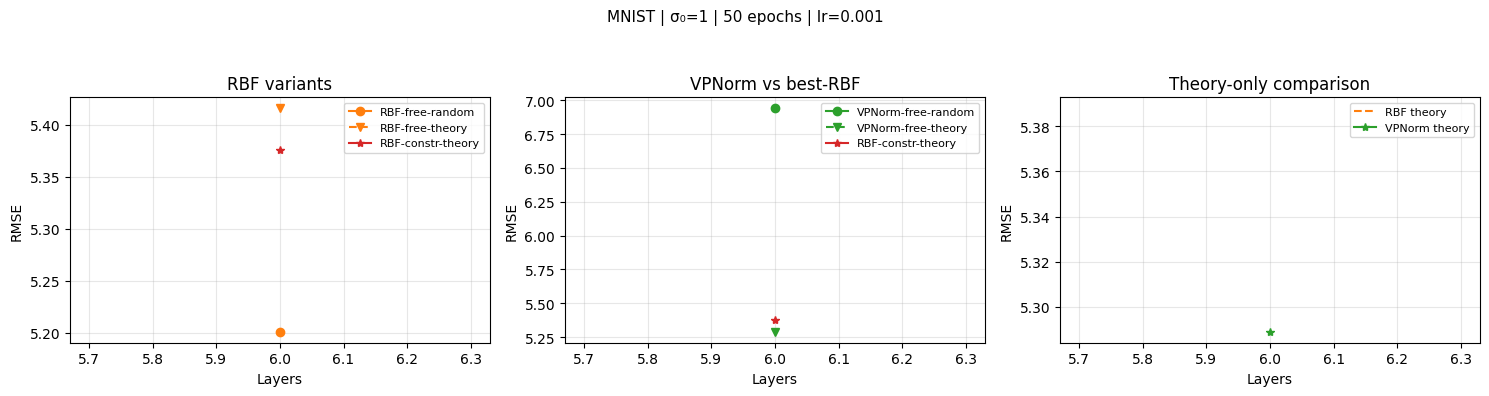

In [1]:
import math, time, csv, datetime as dt, re, importlib.util
from pathlib import Path
from typing import Dict

import torch, torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

#  sweep hyper-params 
LAYER_LIST   = [6]
EPOCHS_EACH  = 50
LR_INIT      = 1e-3
NOISE_STD    = 1
BATCH_SZ     = 4096
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from pathlib import Path
ROOT = Path.cwd()          # folder that the notebook is in
BASE_DIR = ROOT / "fast_layersweeps_mnist"
src      = ROOT / "DenoisingTesting.py"
OUT_DIR  = BASE_DIR / f"fast_layersweep_mnist_{dt.datetime.now():%Y%m%d_%H%M}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

#  dataset: raw + unit copies 
to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
mnist   = torchvision.datasets.MNIST("./data", train=True, download=True,
                                     transform=to_flat)

raw_all = torch.stack([x for x, _ in mnist]).to(device)       # [60k,784]
N       = len(raw_all); n_train = int(0.9*N)
torch.manual_seed(0)
perm    = torch.randperm(N, device=device)
train_idx, test_idx = perm[:n_train], perm[n_train:]

#train_raw, test_raw = raw_all, raw_all

# ── FIX: keep training keys strictly on the train split ──
train_raw = raw_all[train_idx]          # [54 000, 784]
test_raw  = raw_all[test_idx]           # [ 6 000, 784]

# index tensors must now refer to these *local* rows, not the
# original 0‥59 999 indices
train_idx = torch.arange(train_raw.size(0), device=device)     # 0‥53 999
test_idx  = torch.arange(test_raw.size(0),  device=device)     # 0‥5 999

train_norms = train_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
test_norms  = test_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
train_unit  = train_raw / train_norms
test_unit   = test_raw  / test_norms

MEAN_NORM   = train_norms.mean().item()          # ≈ 6.6
SIGMA0_UNIT = NOISE_STD / MEAN_NORM              # used for VPNorm theory

#  import model + helpers 

spec= importlib.util.spec_from_file_location("denoise", src)
den = importlib.util.module_from_spec(spec); spec.loader.exec_module(den)  # type: ignore

DenoiseTransformer   = den.DenoiseTransformer
theory_initialise    = den.theory_initialise
_enforce_constraint  = den._enforce_gamma_constraint

#  checkpoint helpers 
NAME_RE = re.compile(
    r"""ckpt_(?P<tag>.+?)_L(?P<L>\d+)_ep(?P<ep>\d+)_lr(?P<lr>[\d.]+)
        _sig(?P<sig>[\d.]+)\.pt$""", re.X)

def fname(tag:str,L:int)->str:
    return f"ckpt_{tag}_L{L}_ep{EPOCHS_EACH}_lr{LR_INIT:g}_sig{NOISE_STD:g}.pt"

def find_ckpt(tag:str,L:int)->Path|None:
    patt=f"ckpt_{tag}_L{L}_ep*_lr*_sig*.pt"
    for p in sorted(BASE_DIR.rglob(patt), key=lambda p:p.stat().st_mtime, reverse=True):
        m=NAME_RE.match(p.name)
        if not m: continue
        if int(m["ep"])!=EPOCHS_EACH: continue
        if abs(float(m["lr"])-LR_INIT)>1e-9: continue
        if abs(float(m["sig"])-NOISE_STD)>1e-9: continue
        return p
    return None

# ───────── helpers: noise & training ─────────
def add_unit_noise(raw:torch.Tensor, norms:torch.Tensor):
    eps=torch.randn_like(raw)
    return raw/norms + (NOISE_STD/norms)*eps, norms   # unit vec + scaled noise

def train_quick(model, *, kernel:str, constr:bool, steps:int):
    opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                         lr=LR_INIT, betas=(0.9,0.99))
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps, LR_INIT*1e-2)
    scaler=GradScaler()
    model.train()
    inner=tqdm(range(steps), desc="train", position=1, leave=False)
    for _ in inner:
        q=train_idx[torch.randint(0,n_train,(BATCH_SZ,),device=device)]
        if kernel=="vpnorm":
            cln_raw=train_raw[q]; norms=cln_raw.norm(dim=1,keepdim=True).clamp_min(1e-8)
            noisy_unit,_=add_unit_noise(cln_raw,norms)
            keys=train_unit; tgt_raw=cln_raw
        else:
            cln_raw=train_raw[q]
            noisy_raw=cln_raw + NOISE_STD*torch.randn_like(cln_raw)
            keys=train_raw; tgt_raw=cln_raw

        if constr: _enforce_constraint(model)

        with autocast():
            out_raw = (model(keys,noisy_unit)*norms if kernel=="vpnorm"
                       else model(keys,noisy_raw))
            loss=F.mse_loss(out_raw, tgt_raw)

        opt.zero_grad(); scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sch.step()
        inner.set_postfix(loss=f"{loss.item():.3e}")

@torch.no_grad()
def compute_rmse(model, *, kernel:str)->float:
    model.eval(); se,n=0.0,0
    for s in range(0,len(test_idx),BATCH_SZ):
        idx=test_idx[s:s+BATCH_SZ]
        if kernel=="vpnorm":
            cln_raw=test_raw[idx]; norms=test_norms[idx]
            noisy_unit,_=add_unit_noise(cln_raw,norms)
            out_raw=model(train_unit,noisy_unit)*norms
        else:
            cln_raw=test_raw[idx]
            noisy_raw=cln_raw + NOISE_STD*torch.randn_like(cln_raw)
            out_raw=model(train_raw,noisy_raw)
        se+=F.mse_loss(out_raw,cln_raw,reduction='sum').item(); n+=cln_raw.size(0)
    return math.sqrt(se/n)

#  sweep grid 
cfgs=[("rbf","free","random"),
      ("rbf","free","theory"),
      ("rbf","constr","theory"),
      ("vpnorm","free","random"),
      ("vpnorm","free","theory")]
all_cols={f"{k}_{c}_{i}" for k,c,i in cfgs} | {"rbf_theory","vpnorm_theory"}

#  sweep loop 
results: Dict[int,Dict[str,float]]={L:{} for L in LAYER_LIST}
t0=time.time()
outer=tqdm(LAYER_LIST, desc="MNIST Layers", position=0)

for done,L in enumerate(outer,1):
    for kernel,mode,init in cfgs:
        constr=(mode=="constr")
        tag=f"{kernel}_{mode}_{init}"
        ckpt=find_ckpt(tag,L)
        if ckpt:
            state=torch.load(ckpt,map_location="cpu")
            mdl  = DenoiseTransformer(L,kernel=kernel).to(device)
            mdl.load_state_dict(state["state_dict"] if isinstance(state,dict) else state, strict=False)
            print(f"✓ reuse {ckpt.relative_to(BASE_DIR)}")
        else:
            mdl=DenoiseTransformer(L,kernel=kernel).to(device)
            if constr:
                for lyr in mdl.layers: lyr.log_gamma.requires_grad_(False)
            if init=="theory":
                sigma0 = SIGMA0_UNIT if kernel=="vpnorm" else NOISE_STD
                theory_initialise(mdl, sigma0=sigma0, sigma_min=sigma0*1e-3)
            steps=int(EPOCHS_EACH*n_train/BATCH_SZ)
            train_quick(mdl,kernel=kernel,constr=constr,steps=steps)
            torch.save({"state_dict":mdl.state_dict(),
                        "meta":{"ep":EPOCHS_EACH,"lr":LR_INIT,"sig":NOISE_STD}},
                       OUT_DIR/fname(tag,L))
        results[L][tag]=compute_rmse(mdl,kernel=kernel)

    # free-theory baselines
    for k in ["rbf","vpnorm"]:
        key=f"{k}_theory"
        if key not in results[L]:
            m0=DenoiseTransformer(L,kernel=k).to(device)
            sigma0=SIGMA0_UNIT if k=="vpnorm" else NOISE_STD
            theory_initialise(m0, sigma0=sigma0, sigma_min=sigma0*1e-3)
            results[L][key]=compute_rmse(m0,kernel=k)

    elapsed=time.time()-t0
    outer.set_postfix(elapsed=f"{elapsed/60:.1f}m",
                      eta=f"{(len(LAYER_LIST)-done)*(elapsed/done)/60:.1f}m")
    outer.update(0)

outer.close()

#  save CSV 
csv_p=OUT_DIR/"results.csv"
with open(csv_p,"w",newline="") as f:
    hdr=["layers"]+sorted(all_cols); w=csv.writer(f); w.writerow(hdr)
    for L in LAYER_LIST:
        w.writerow([L]+[results[L].get(c,"") for c in hdr[1:]])
print("CSV →",csv_p)

# plots 
x=np.array(LAYER_LIST,float)
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(x,[results[L]['rbf_free_random']  for L in LAYER_LIST],"C1o-",label='RBF-free-random')
plt.plot(x,[results[L]['rbf_free_theory']  for L in LAYER_LIST],"C1v--",label='RBF-free-theory')
plt.plot(x,[results[L]['rbf_constr_theory']for L in LAYER_LIST],"C3*-",label='RBF-constr-theory')
plt.title("RBF variants"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.subplot(1,3,2)
plt.plot(x,[results[L]['vpnorm_free_random'] for L in LAYER_LIST],"C2o-",label='VPNorm-free-random')
plt.plot(x,[results[L]['vpnorm_free_theory'] for L in LAYER_LIST],"C2v--",label='VPNorm-free-theory')
plt.plot(x,[results[L]['rbf_constr_theory']  for L in LAYER_LIST],"C3*-",label='RBF-constr-theory')
plt.title("VPNorm vs best-RBF"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.subplot(1,3,3)
plt.plot(x,[results[L]['rbf_theory']    for L in LAYER_LIST],"C1--",label='RBF theory')
plt.plot(x,[results[L]['vpnorm_theory'] for L in LAYER_LIST],"C2*-",label='VPNorm theory')
plt.title("Theory-only comparison"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.suptitle(f"MNIST | σ₀={NOISE_STD} | {EPOCHS_EACH} epochs | lr={LR_INIT}", fontsize=11)
plt.tight_layout(rect=[0,0,1,0.93])
img_p = OUT_DIR/"layer_plot.png"; plt.savefig(img_p,dpi=200)
print("Plot →",img_p)
plt.show()


using fast_layersweep_mnist_20250730_0133/ckpt_rbf_free_theory_L6_ep50_lr0.001_sig1.pt (ep50)
using fast_layersweep_mnist_20250730_0133/ckpt_vpnorm_free_theory_L6_ep50_lr0.001_sig1.pt (ep50)
Plot → plots/CIFAR10_layer_progression_20250730_020740.png


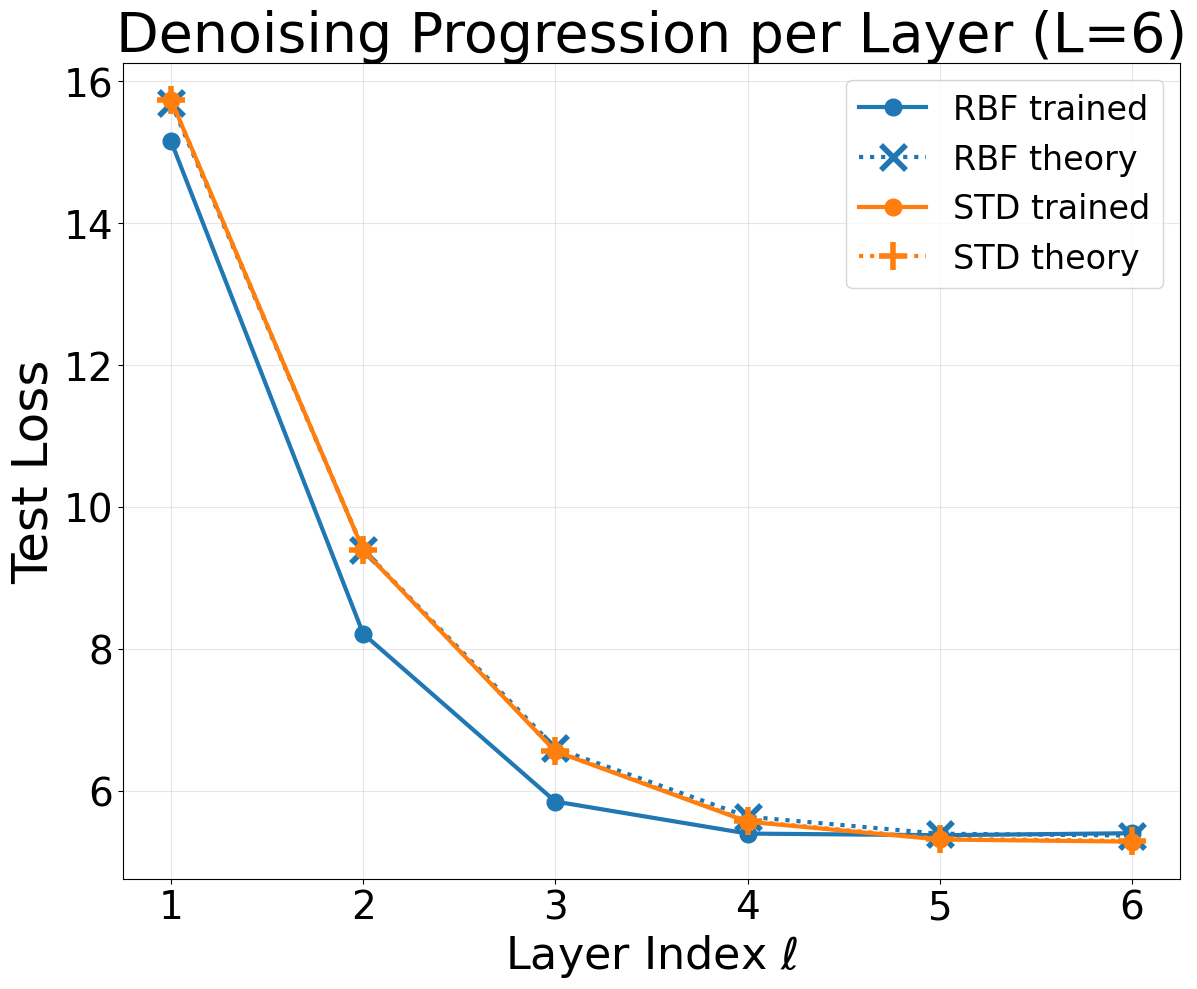

In [3]:

# [MNIST LAYER-PROGRESSION PLOT]  RMSE after each layer (default L=6)
#
#   • Looks for the highest-epoch checkpoint (or EXACT_EPOCH if set)
#     for each cfg in CFG_COMPARE, using the *MNIST* sweep directory.
#   • Computes test-set RMSE after layers ℓ = 1…L for each model.
#   • Plots trained RBF vs STD (VPNorm) plus their closed-form theory curves.
#
# Prereqs: the MNIST sweep cell (v4) has already created
#   train_raw, train_unit, test_raw, test_norms, add_unit_noise, etc.


import datetime as dt, math, sys, re, csv
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np

#  user-tunable options 
DESIRED_LAYERS = 6                 # default L
EXACT_EPOCH    = None              # set an int to force that epoch
MIN_EPOCHS     = 50                # otherwise use max ≥ this
CFG_COMPARE = [
    ("rbf",    "free",   "theory"),   # trained RBF
    ("vpnorm", "free",   "theory"),   # trained STD (VPNorm)
]
STYLE = {
    "rbf":    dict(color="C0", solid_marker="o", theory_marker="x"),
    "vpnorm": dict(color="C1", solid_marker="o", theory_marker="+"),
}

#  paths & regex (MNIST dir) 
MNIST_BASE_DIR = ROOT / "fast_layersweeps_mnist"
NAME_RE = re.compile(
    r"""ckpt_(?P<tag>.+?)_L(?P<L>\d+)_ep(?P<ep>\d+)_lr(?P<lr>[\d.]+)
        _sig(?P<sig>[\d.]+)\.pt$""", re.X)

def best_ckpt(tag:str, L:int):
    best_path, best_ep = None, -1
    for p in MNIST_BASE_DIR.rglob(f"ckpt_{tag}_L{L}_ep*_lr*_sig*.pt"):
        m = NAME_RE.match(p.name)
        if not m: continue
        if abs(float(m["lr"])-LR_INIT)>1e-9 or abs(float(m["sig"])-NOISE_STD)>1e-9:
            continue
        ep = int(m["ep"])
        if EXACT_EPOCH is not None and ep != EXACT_EPOCH:
            continue
        if ep >= MIN_EPOCHS and ep > best_ep:
            best_path, best_ep = p, ep
    return best_path, best_ep if best_ep>=0 else None

#  RMSE progression helper 
@torch.no_grad()
def rmse_progression(model, *, kernel:str):
    L = len(model.layers)
    se = [0.0]*L
    n  = 0
    for s in range(0, len(test_idx), BATCH_SZ):
        idx = test_idx[s:s+BATCH_SZ]
        if kernel == "vpnorm":
            cln_raw = test_raw[idx]; norms = test_norms[idx]
            noisy_unit, _ = add_unit_noise(cln_raw, norms)
            q = noisy_unit.clone()
            keys = train_unit
        else:
            cln_raw = test_raw[idx]
            noisy_raw = cln_raw + NOISE_STD * torch.randn_like(cln_raw)
            q = noisy_raw.clone()
            keys = train_raw

        q = q.to(device); keys = keys.to(device); tgt = cln_raw.to(device)
        for k, layer in enumerate(model.layers):
            q = layer(keys, q)
            q_out = q * norms.to(device) if kernel=="vpnorm" else q
            se[k] += torch.nn.functional.mse_loss(q_out, tgt, reduction="sum").item()
        n += tgt.size(0)
    return [math.sqrt(s / n) for s in se]

#  gather curves 
layer_ticks = np.arange(1, DESIRED_LAYERS+1)
out_curves  = {}
for kernel, mode, init in CFG_COMPARE:
    tag = f"{kernel}_{mode}_{init}"
    path, ep = best_ckpt(tag, DESIRED_LAYERS)
    if path is None:
        print(f"!! no checkpoint for {tag}", file=sys.stderr); continue
    print(f"using {path.relative_to(MNIST_BASE_DIR)} (ep{ep})")
    mdl = DenoiseTransformer(DESIRED_LAYERS, kernel=kernel).to(device)
    state = torch.load(path, map_location="cpu")
    mdl.load_state_dict(state["state_dict"] if isinstance(state,dict) else state,
                        strict=False)
    out_curves[(kernel, "trained")] = rmse_progression(mdl, kernel=kernel)

    m_th = DenoiseTransformer(DESIRED_LAYERS, kernel=kernel).to(device)
    sigma0 = SIGMA0_UNIT if kernel=="vpnorm" else NOISE_STD
    theory_initialise(m_th, sigma0=sigma0, sigma_min=sigma0*1e-3)
    out_curves[(kernel, "theory")]  = rmse_progression(m_th, kernel=kernel)
#  plot (STD vs RBF) 
import datetime as dt
from pathlib import Path
import matplotlib.pyplot as plt

PLOTS_DIR = Path("./plots"); PLOTS_DIR.mkdir(exist_ok=True)
stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

fig, ax = plt.subplots(figsize=(12, 10))
for kernel in ["rbf", "vpnorm"]:
    if (kernel, "trained") not in out_curves:
        continue

    style = STYLE[kernel]
    display_name = "STD" if kernel == "vpnorm" else kernel.upper()

    # trained curve
    ax.plot(
        layer_ticks,
        out_curves[(kernel, "trained")],
        color=style["color"],
        marker=style["solid_marker"],
        markersize=12,
        linewidth=3,
        label=f"{display_name} trained",
    )

    # theory curve
    ax.plot(
        layer_ticks,
        out_curves[(kernel, "theory")],
        color=style["color"],
        marker=style["theory_marker"],
        markersize=20 if kernel == "vpnorm" else 18,
        markeredgewidth=4,
        linewidth=3,
        linestyle=":",
        label=f"{display_name} theory",
    )

ax.set_xlabel(r"Layer Index $\ell$", fontsize=32)
ax.set_ylabel("Test Loss", fontsize=36)
ax.set_title("Denoising Progression per Layer (L=6)", fontsize=40)
ax.tick_params(axis="both", labelsize=28)
ax.grid(alpha=0.3)
ax.legend(fontsize=24, loc="best")

fig.tight_layout()
fname = PLOTS_DIR / f"CIFAR10_layer_progression_{stamp}.png"
fig.savefig(fname, dpi=200)
print("Plot →", fname)
plt.show()
